In [1]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from collections import defaultdict, Counter

In [2]:
def createDf(data):
    reformed_data = []
    for exp in data:
        base_data = { k:v for k,v in exp.items() if k != "track" }
        for class_name, class_info in exp["track"].items():
            for n_frame, frame_tracks in enumerate(class_info):
                for tracker_id, player_dict in frame_tracks.items():
                    row = base_data.copy()
                    row.update({'class_name': class_name, 'frame': n_frame, 'tracker_id': tracker_id})
                    row.update({
                        "x1": player_dict["bbox"][0],
                        "y1": player_dict["bbox"][1],
                        "w": player_dict["bbox"][2] - player_dict["bbox"][0],
                        "h": player_dict["bbox"][3] - player_dict["bbox"][1],
                        "bbox_size": player_dict["bbox_size"],
                        "confidence": player_dict["confidence"],
                        "Real Madrid": player_dict["distances"]["Real Madrid"],
                        "Wolfsburgo": player_dict["distances"]["Wolfsburgo"],
                        "L": player_dict["shirt_color"][0],
                        "A": player_dict["shirt_color"][1],
                        "B": player_dict["shirt_color"][2],
                        "team": player_dict["team"]
                    } )
                    reformed_data.append(row)
    return pd.DataFrame(reformed_data)

In [3]:
with open("../tracks3.json", "r", encoding="utf-8") as f:
    data3 = json.load(f)
df3 = createDf(data3)
df3

,conf,mcf,mt,tt,class_name,frame,tracker_id,x1,y1,w,h,bbox_size,confidence,Real Madrid,Wolfsburgo,L,A,B,team
0,0.01,1,0.933,0.1,ball,0,23,1186.531494,848.252991,17.196899,18.936218,969,0.368043,11.816157,35.026048,228.339623,118.773585,135.452830,Real Madrid
1,0.01,1,0.933,0.1,ball,1,23,1186.724854,847.940369,16.663696,19.292908,1020,0.322803,11.888387,37.069459,224.210526,119.701754,134.140351,Real Madrid
2,0.01,1,0.933,0.1,ball,15,27,1217.013428,720.452637,47.154663,92.119263,5478,0.012704,183.791802,187.411972,46.982759,123.876437,133.597701,Real Madrid
3,0.01,1,0.933,0.1,ball,88,115,257.489349,794.939392,15.883118,23.411865,1152,0.575783,12.964277,41.778587,240.974359,123.769231,132.307692,Real Madrid
4,0.01,1,0.933,0.1,ball,89,115,258.835266,790.507507,14.205688,22.799194,1035,0.549380,8.498866,41.266353,226.322581,124.387097,131.870968,Real Madrid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426603,0.20,10,1.000,0.7,referee,195,3,798.576294,275.170807,12.810608,37.161102,4356,0.747764,29.224592,59.854649,202.060185,125.004630,118.462963,Real Madrid
426604,0.20,10,1.000,0.7,referee,196,3,797.570618,275.090576,12.941162,37.297607,3960,0.737760,5.280152,45.231591,226.215385,124.569231,127.192308,Real Madrid
426605,0.20,10,1.000,0.7,referee,197,3,797.412048,275.300659,12.984009,37.230194,4095,0.729366,3.432941,47.649502,227.312217,123.597285,123.687783,Real Madrid
426606,0.20,10,1.000,0.7,referee,198,3,797.832275,274.968567,13.224609,36.390930,3078,0.748680,53.653958,21.895477,209.645570,92.898734,163.835443,Wolfsburgo


In [4]:
def analyze_tracks_no_gt(tracks, class_name="player"):
    frames = tracks[class_name]
    T = len(frames)
    id_frames, id_teams, id_colors, id_bboxes, id_conf, id_bbox_sizes = defaultdict(list), defaultdict(list), defaultdict(list), defaultdict(list), defaultdict(list), defaultdict(list), 
    
    for t, frame_dict in enumerate(frames):
        for tid, info in frame_dict.items():
            id_frames[tid].append(t)
            id_teams[tid].append(info['team']), id_colors[tid].append(info['shirt_color']), id_bboxes[tid].append(info['bbox']), id_conf[tid].append(info['confidence']), id_bbox_sizes[tid].append(info['bbox_size'])
    
    # Metrics per id
    metrics = {}
    num_tracks = 0
    for tid, frames_seen in id_frames.items():
        
        if int(tid) > num_tracks:    num_tracks = int(tid)
        
        frames_seen_sorted = sorted(frames_seen)
        total_seen = len(frames_seen_sorted)
        coverage = total_seen / T

        gap_lengths = []
        movimiento_x = []
        movimiento_y = []
        prev = frames_seen_sorted[0]
        bbox_prev = id_bboxes[tid][0]
        for n_frame, f in enumerate(frames_seen_sorted[1:]):
            frame_gap = f - prev - 1
            if f != prev +1 :
                gap_lengths.append(frame_gap)

            bbox_current = id_bboxes[tid][n_frame]
            x1, y1, _, _ = bbox_current
            x1_prev, y1_prev, _, _ = bbox_prev

            dx, dy = (x1 - x1_prev) / (frame_gap+1), (y1 - y1_prev) / (frame_gap+1)

            movimiento_x.append(dx),  movimiento_y.append(dy)

            prev = f
            bbox_prev = bbox_current

        gaps = len(gap_lengths)
        mean_gap_len = np.mean(gap_lengths) if gap_lengths else 0.0
        mean_speed = np.mean(np.sqrt(np.array(movimiento_x)**2 + np.array(movimiento_y)**2)) if movimiento_x else 0.0
        max_speed = np.max(np.sqrt(np.array(movimiento_x)**2 + np.array(movimiento_y)**2)) if movimiento_x else 0.0
        
        # team stability
        teams = id_teams.get(tid, [])
        team_mode = None
        flip_rate_static, flip_rate_dynamic, entropy = 0.0, 0.0, 0.0
        if teams:
            c = Counter(teams)
            team_mode, _ = c.most_common(1)[0]
            flips_static = sum(1 for x in teams if x != team_mode)
            flips_dynamic = sum(teams[i] != teams[i - 1] for i in range(1, len(teams)))
            flip_rate_static = flips_static / len(teams) if teams else None
            flip_rate_dynamic = flips_dynamic / (len(teams) - 1) if len(teams) > 1 else None

            # entropy
            ps = np.array(list(c.values()))/sum(c.values())
            entropy = -np.sum(ps * np.log2(ps + 1e-12))
        
        # color variance (if numeric)
        colors = np.array(id_colors.get(tid, []), dtype=float) if id_colors.get(tid) else None
        color_var = float(np.mean(np.var(colors, axis=0))) if colors is not None and len(colors)>0 else None
        color_diff = float(np.mean(np.linalg.norm(np.diff(colors, axis=0), axis=1))) if colors is not None and len(colors)>0 else None
        
        # bbox size var
        sizes = np.array(id_bbox_sizes.get(tid, []), dtype=float) if id_bbox_sizes.get(tid) else None
        size_cv = (np.std(sizes)/np.mean(sizes)) if sizes is not None and len(sizes)>1 else None
        
        metrics[tid] = {
            "coverage": coverage, "total_seen": total_seen, "fragments": gaps, "mean_gap_len": mean_gap_len, "mean_speed": mean_speed, "max_speed": max_speed,
            "team_mode": team_mode, "team_flip_rate_static": flip_rate_static, "team_flip_rate_dynamic": flip_rate_dynamic, "team_entropy": entropy,
            "color_var": color_var, "color_diff": color_diff, "bbox_size_cv": size_cv, "mean_confidence": float(np.mean(id_conf[tid])) if id_conf.get(tid) else None
        }
    # Summary stats
    covs = [m["coverage"] for m in metrics.values()]
    total_seen = [m["total_seen"] for m in metrics.values()]
    frag = [m["fragments"] for m in metrics.values()]
    mean_gap_len = [m["mean_gap_len"] for m in metrics.values()]
    mean_speed = [m["mean_speed"] for m in metrics.values()]
    max_speed = [m["max_speed"] for m in metrics.values()]
    flip_rates_static  = [m["team_flip_rate_static" ] for m in metrics.values() if m["team_flip_rate_static"] is not None]
    flip_rates_dynamic = [m["team_flip_rate_dynamic"] for m in metrics.values() if m["team_flip_rate_dynamic"] is not None]
    entropy = [m["team_entropy"] for m in metrics.values()]
    color_var = [m["color_var"] for m in metrics.values()]
    color_diff = [m["color_diff"] for m in metrics.values()]
    bbox_size = [m["bbox_size_cv"] for m in metrics.values() if m["bbox_size_cv"] is not None]
    confidence = [m["mean_confidence"] for m in metrics.values() if m["mean_confidence"] is not None]

    summary = {
        "n_tracks": num_tracks,
        "num_tracks": len(metrics),

        "mean_coverage": float(np.mean(covs)) if covs else 0.0, "median_coverage": float(np.median(covs)) if covs else 0.0, "25_coverage": float(np.quantile(covs, 0.25)) if covs else 0.0,
        "mean_fragments": float(np.mean(frag)) if frag else 0.0, "median_fragments": float(np.median(frag)) if frag else 0.0, "mean_gap_len_mean": float(np.mean(mean_gap_len)) if mean_gap_len else 0.0, "median_gap_len_mean": float(np.median(mean_gap_len)) if mean_gap_len else 0.0, 
        
        "pct_tracks_with_fragments": float(np.mean([1 if f>0 else 0 for f in frag])) if frag else 0.0,

        "mean_speed": float(np.mean(mean_speed) if mean_speed else 0.0),
        "max_speed": float(np.mean(max_speed) if max_speed else 0.0),
        
        "mean_team_flip_rate": float(np.mean(flip_rates_static)) if flip_rates_static else 0.0,
        "mean_team_flip_dynamic": float(np.mean(flip_rates_dynamic)) if flip_rates_dynamic else 0.0,
        "entropy": float(np.mean(entropy)) if entropy else 0.0,
        "color_var": float(np.mean(color_var)) if color_var else 0.0,
        "color_diff": float(np.mean(color_diff)) if color_diff else 0.0,
        "bbox_size": float(np.mean(bbox_size)) if bbox_size else 0.0,
        "confidence": float(np.mean(confidence)) if confidence else 0.0,
    }
    return metrics, summary

In [5]:
rows = []
for exp in data3:
    metrics, summary = analyze_tracks_no_gt(exp["track"])
    row = exp
    row["metrics"] = metrics
    row["summary"] = summary
    rows.append(row)

c:\Users\hecto\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\hecto\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [6]:
for i, exp in enumerate(rows):
    exp['experiment_id'] = i
    
df_summary = pd.DataFrame([
    {
        **{k: v for k, v in exp.items() if k not in ['metrics', 'summary', 'track']},
        **exp['summary']
    }
    for exp in rows
])

df_summary

,conf,mcf,mt,tt,experiment_id,n_tracks,num_tracks,mean_coverage,median_coverage,25_coverage,...,pct_tracks_with_fragments,mean_speed,max_speed,mean_team_flip_rate,mean_team_flip_dynamic,entropy,color_var,color_diff,bbox_size,confidence
0,0.01,1,0.933,0.1,0,200,37,0.549595,0.8000,0.05500,...,0.567568,3.589962,14.967576,0.038732,0.071404,0.176944,302.833914,NaN,0.342539,0.696328
1,0.01,5,0.933,0.1,1,27,24,0.824167,0.9650,0.92625,...,0.500000,3.640737,17.349697,0.040882,0.067689,0.222452,331.662375,14.153225,0.412690,0.761480
2,0.01,10,0.933,0.1,2,25,23,0.843696,0.9600,0.92500,...,0.478261,3.601156,17.454373,0.103126,0.136205,0.454357,601.003636,21.029064,0.446602,0.776862
3,0.01,1,0.966,0.1,3,182,36,0.566667,0.8300,0.05375,...,0.583333,3.520267,14.528187,0.044597,0.083930,0.193921,324.538530,NaN,0.372746,0.693336
4,0.01,5,0.966,0.1,4,26,23,0.861087,0.9700,0.94000,...,0.521739,3.717698,17.881530,0.040662,0.062085,0.224816,283.403315,12.734184,0.413854,0.775655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,0.20,5,0.966,0.7,103,24,22,0.822500,0.9425,0.76750,...,0.545455,3.485599,17.081172,0.111599,0.151393,0.471078,477.993066,20.241661,0.458434,0.815489
104,0.20,10,0.966,0.7,104,22,21,0.815714,0.9450,0.63500,...,0.523810,3.490224,17.186509,0.238802,0.278693,0.766334,628.177872,29.995825,0.500849,0.815169
105,0.20,1,1.000,0.7,105,24,21,0.800238,0.9250,0.71000,...,0.714286,9.020187,254.295399,0.184373,0.223175,0.671471,553.614135,24.899805,0.449966,0.822116
106,0.20,5,1.000,0.7,106,20,20,0.792250,0.8900,0.65000,...,0.700000,9.367790,259.903919,0.242225,0.303850,0.772053,527.238607,29.125349,0.491088,0.828255


In [7]:
rows_detailed = []
for exp in rows:
    exp_info = {k: v for k, v in exp.items() if k not in ['metrics', 'summary', 'track']}
    for tid, m in exp['metrics'].items():
        rows_detailed.append({
            **exp_info,
            "track_id": tid,
            **m
        })

df_tracks = pd.DataFrame(rows_detailed)
df_tracks

,conf,mcf,mt,tt,experiment_id,track_id,coverage,total_seen,fragments,mean_gap_len,mean_speed,max_speed,team_mode,team_flip_rate_static,team_flip_rate_dynamic,team_entropy,color_var,color_diff,bbox_size_cv,mean_confidence
0,0.01,1,0.933,0.1,0,1,0.990,198,0,0.000000,3.174913,10.611729,Wolfsburgo,0.015152,0.030457,1.132743e-01,104.582868,5.572413,0.427196,0.838306
1,0.01,1,0.933,0.1,0,2,0.990,198,1,2.000000,3.231374,15.803012,Wolfsburgo,0.030303,0.040609,1.959093e-01,172.358095,7.686460,0.325201,0.792754
2,0.01,1,0.933,0.1,0,3,1.000,200,0,0.000000,2.922286,9.268063,Real Madrid,0.010000,0.020101,8.079314e-02,233.480120,7.450866,0.383706,0.783272
3,0.01,1,0.933,0.1,0,4,1.000,200,0,0.000000,3.556114,14.408763,Wolfsburgo,0.015000,0.030151,1.123607e-01,118.384100,5.901595,0.438116,0.826338
4,0.01,1,0.933,0.1,0,5,1.000,200,0,0.000000,4.051715,15.645078,Real Madrid,0.000000,0.000000,-1.442823e-12,32.661535,2.559568,0.430910,0.857942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2620,0.20,10,1.000,0.7,107,17,0.505,101,10,5.700000,9.831297,178.890645,Real Madrid,0.257426,0.330000,8.228369e-01,397.866999,28.302323,0.429850,0.834852
2621,0.20,10,1.000,0.7,107,18,0.365,73,13,6.615385,24.816982,432.836061,Real Madrid,0.273973,0.375000,8.471075e-01,1385.537534,53.902191,0.488139,0.831535
2622,0.20,10,1.000,0.7,107,14,0.725,145,4,2.000000,10.563703,626.444832,Real Madrid,0.096552,0.173611,4.579685e-01,269.065129,18.879760,0.371242,0.859848
2623,0.20,10,1.000,0.7,107,19,0.435,87,12,5.083333,19.400855,619.552976,Real Madrid,0.298851,0.348837,8.798813e-01,535.295374,31.759197,0.581842,0.818114


In [8]:
df_summary = df_summary[df_summary["n_tracks"] < 30]
df_summary = df_summary[df_summary["mean_fragments"] < 3]
df_summary = df_summary[df_summary["mean_gap_len_mean"] < 4]
len(df_summary)

56

In [9]:
for c in df_summary.columns[:4]:
    print(df_summary[c].value_counts())

conf
0.01    14
0.05    14
0.10    14
0.20    14
Name: count, dtype: int64
mcf
5     24
10    24
1      8
Name: count, dtype: int64
mt
0.933    28
0.966    28
Name: count, dtype: int64
tt
0.70    24
0.10    16
0.35    16
Name: count, dtype: int64


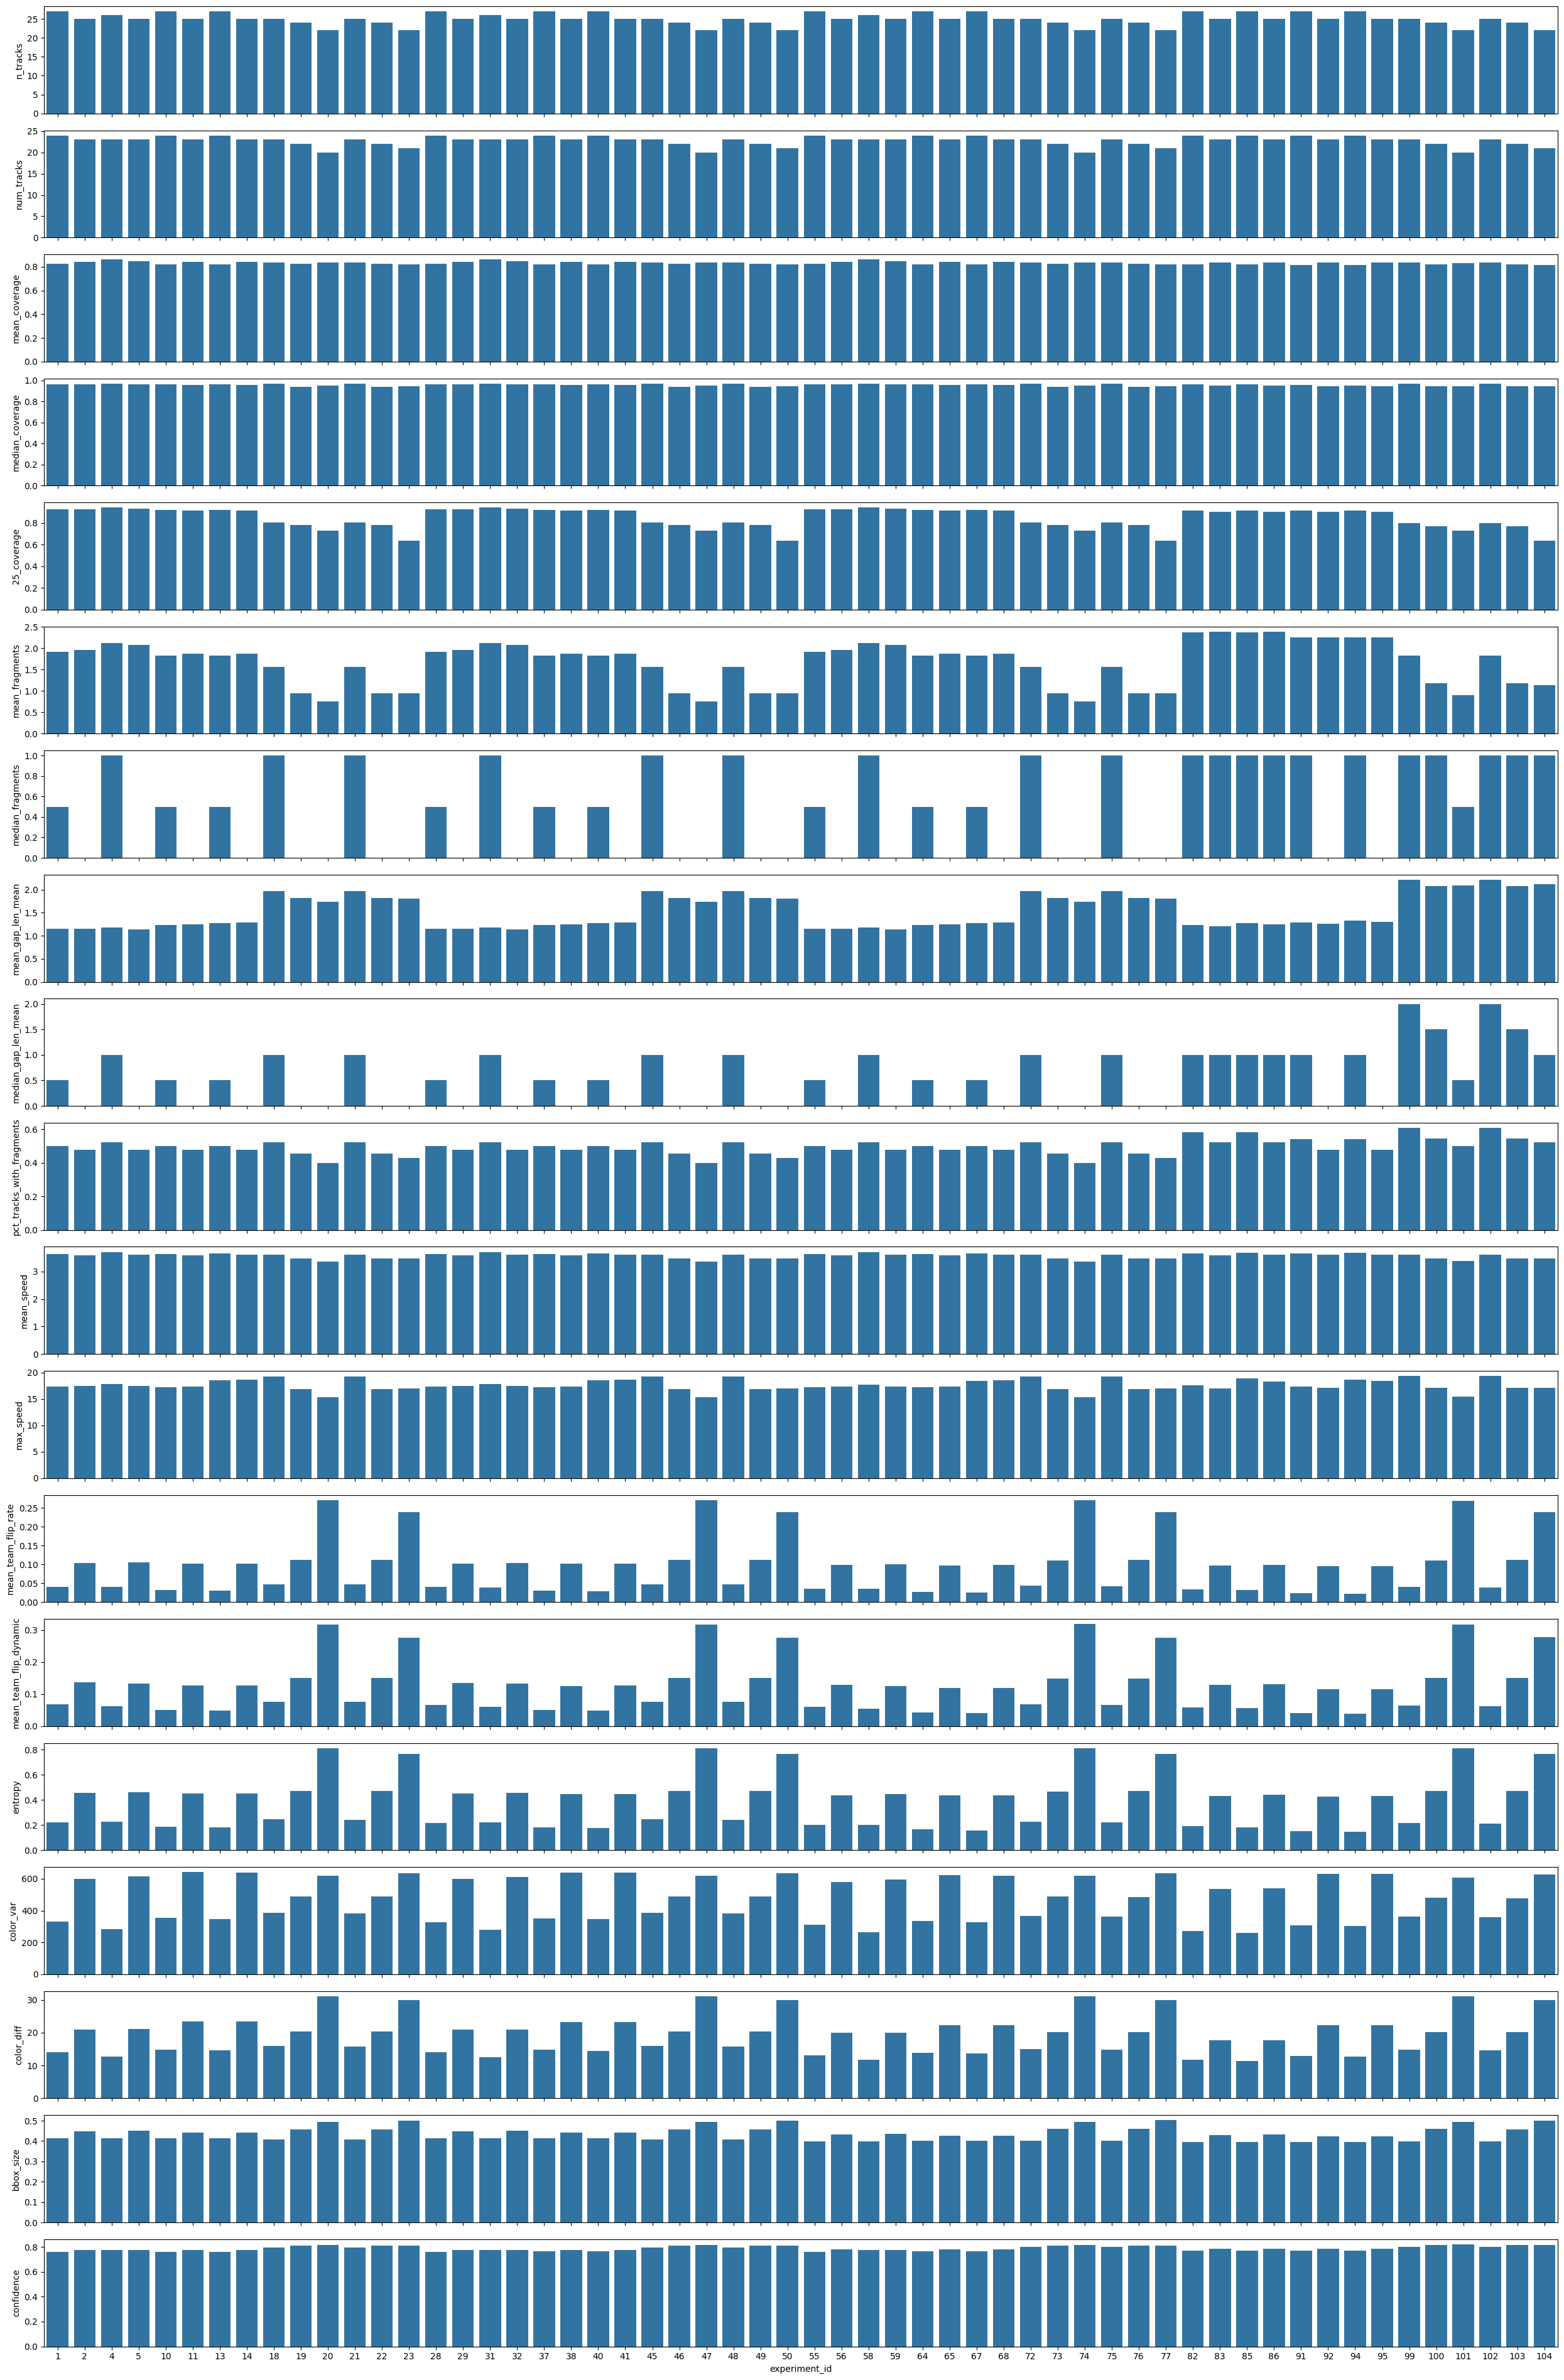

In [10]:
nRows = len(df_summary.columns[5:])
fig, axes = plt.subplots(nRows, 1, figsize=(25,2*nRows), sharex=True)
axes = axes.flatten()
for i, c in enumerate(df_summary.iloc[:, 5:]):
    sns.barplot(data=df_summary, x="experiment_id", y=c, ax=axes[i])
    axes[i].set_ylabel(c)

plt.tight_layout()
plt.show()

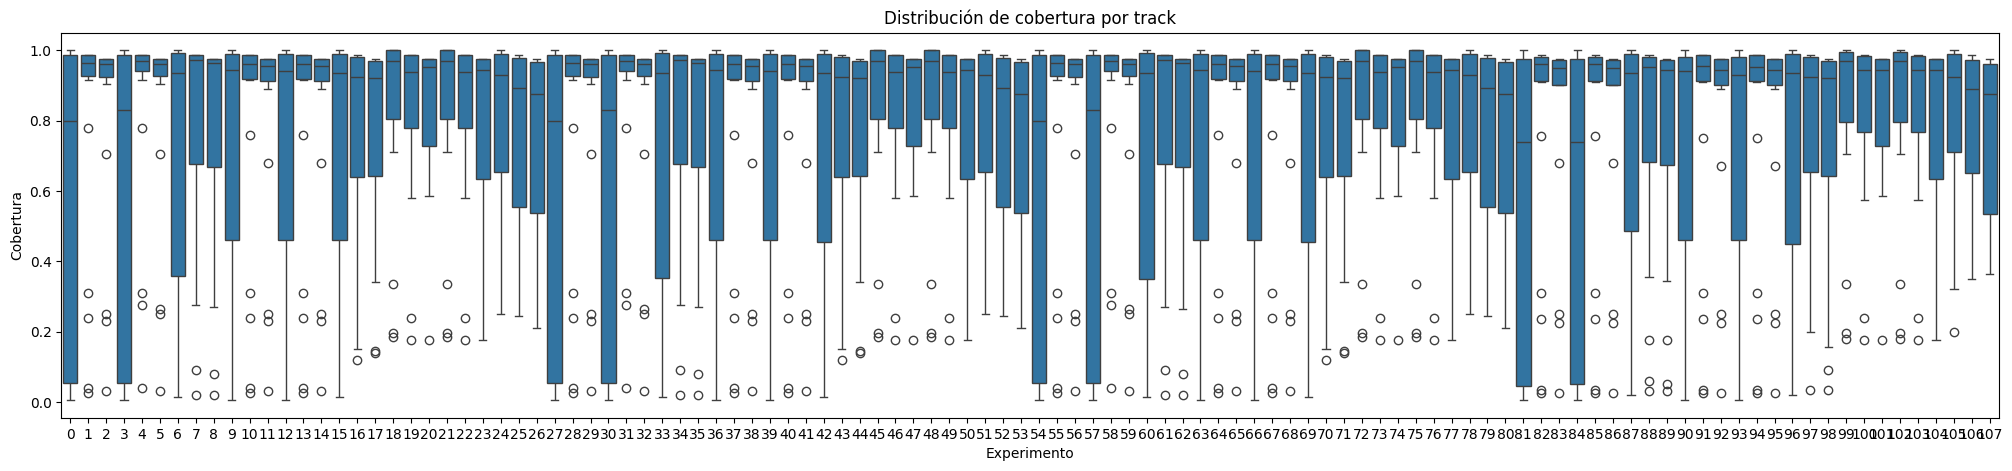

In [11]:
# Distribución de cobertura por track
plt.figure(figsize=(25, 5))
sns.boxplot(data=df_tracks, x="experiment_id", y="coverage")
plt.title("Distribución de cobertura por track")
plt.xlabel("Experimento")
plt.ylabel("Cobertura")
plt.show()

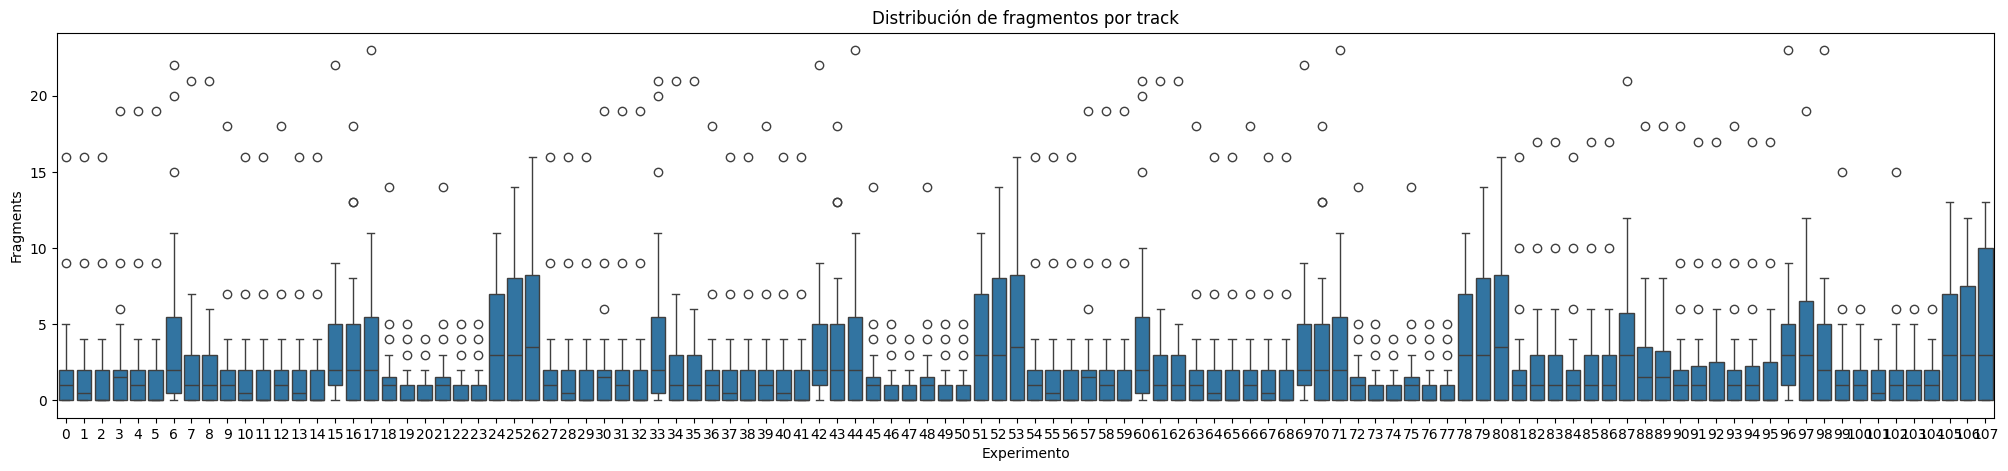

In [12]:
# Distribución de cobertura por track
plt.figure(figsize=(25, 5))
sns.boxplot(data=df_tracks, x="experiment_id", y="fragments")
plt.title("Distribución de fragmentos por track")
plt.xlabel("Experimento")
plt.ylabel("Fragments")
plt.show()

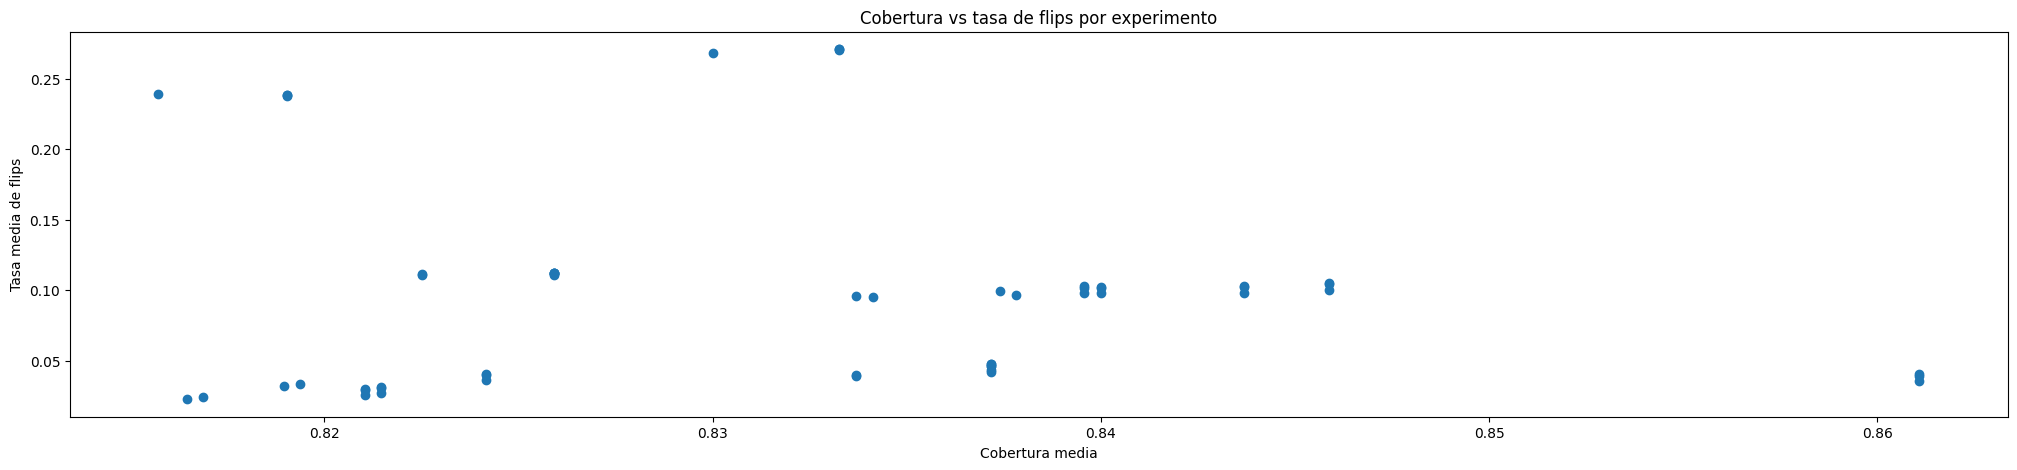

In [13]:
# Scatter: cobertura vs tasa de flips
plt.figure(figsize=(25, 5))
plt.scatter(df_summary["mean_coverage"], df_summary["mean_team_flip_rate"])
plt.xlabel("Cobertura media")
plt.ylabel("Tasa media de flips")
plt.title("Cobertura vs tasa de flips por experimento")
plt.show()

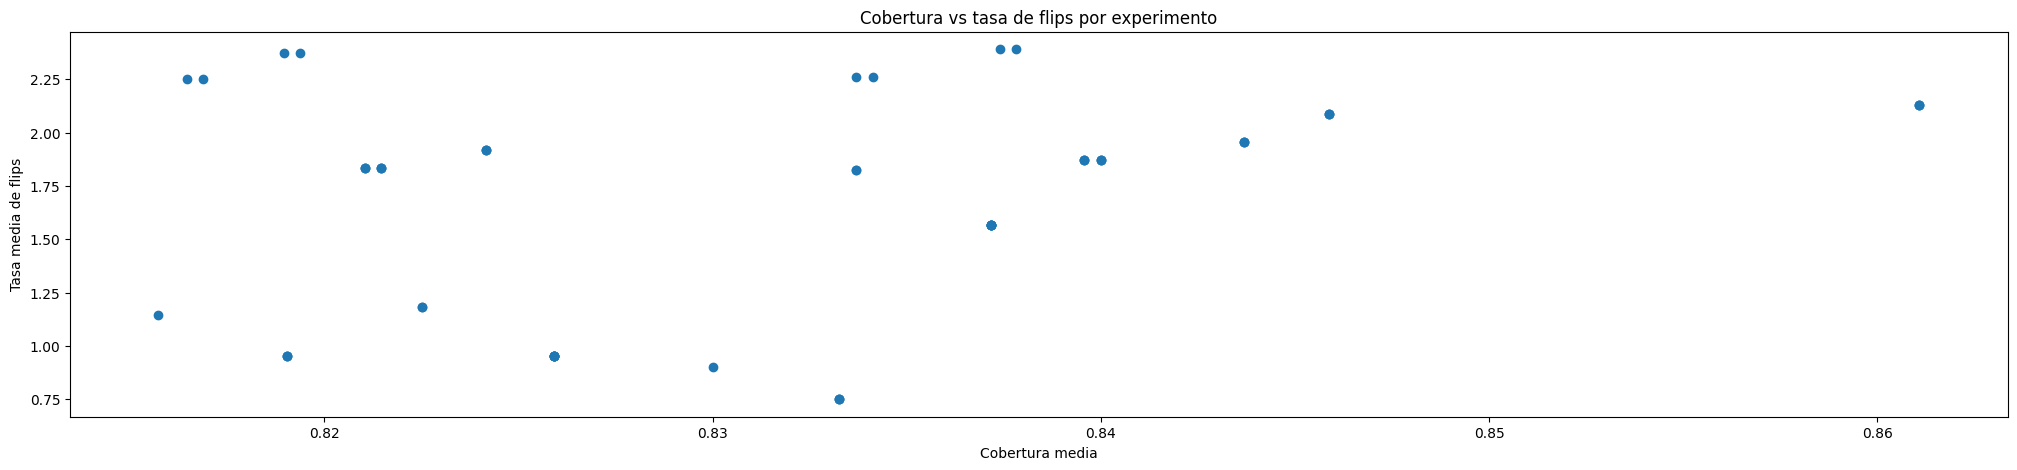

In [14]:
# Scatter: cobertura vs tasa de flips
plt.figure(figsize=(25, 5))
plt.scatter(df_summary["mean_coverage"], df_summary["mean_fragments"])
plt.xlabel("Cobertura media")
plt.ylabel("Tasa media de flips")
plt.title("Cobertura vs tasa de flips por experimento")
plt.show()

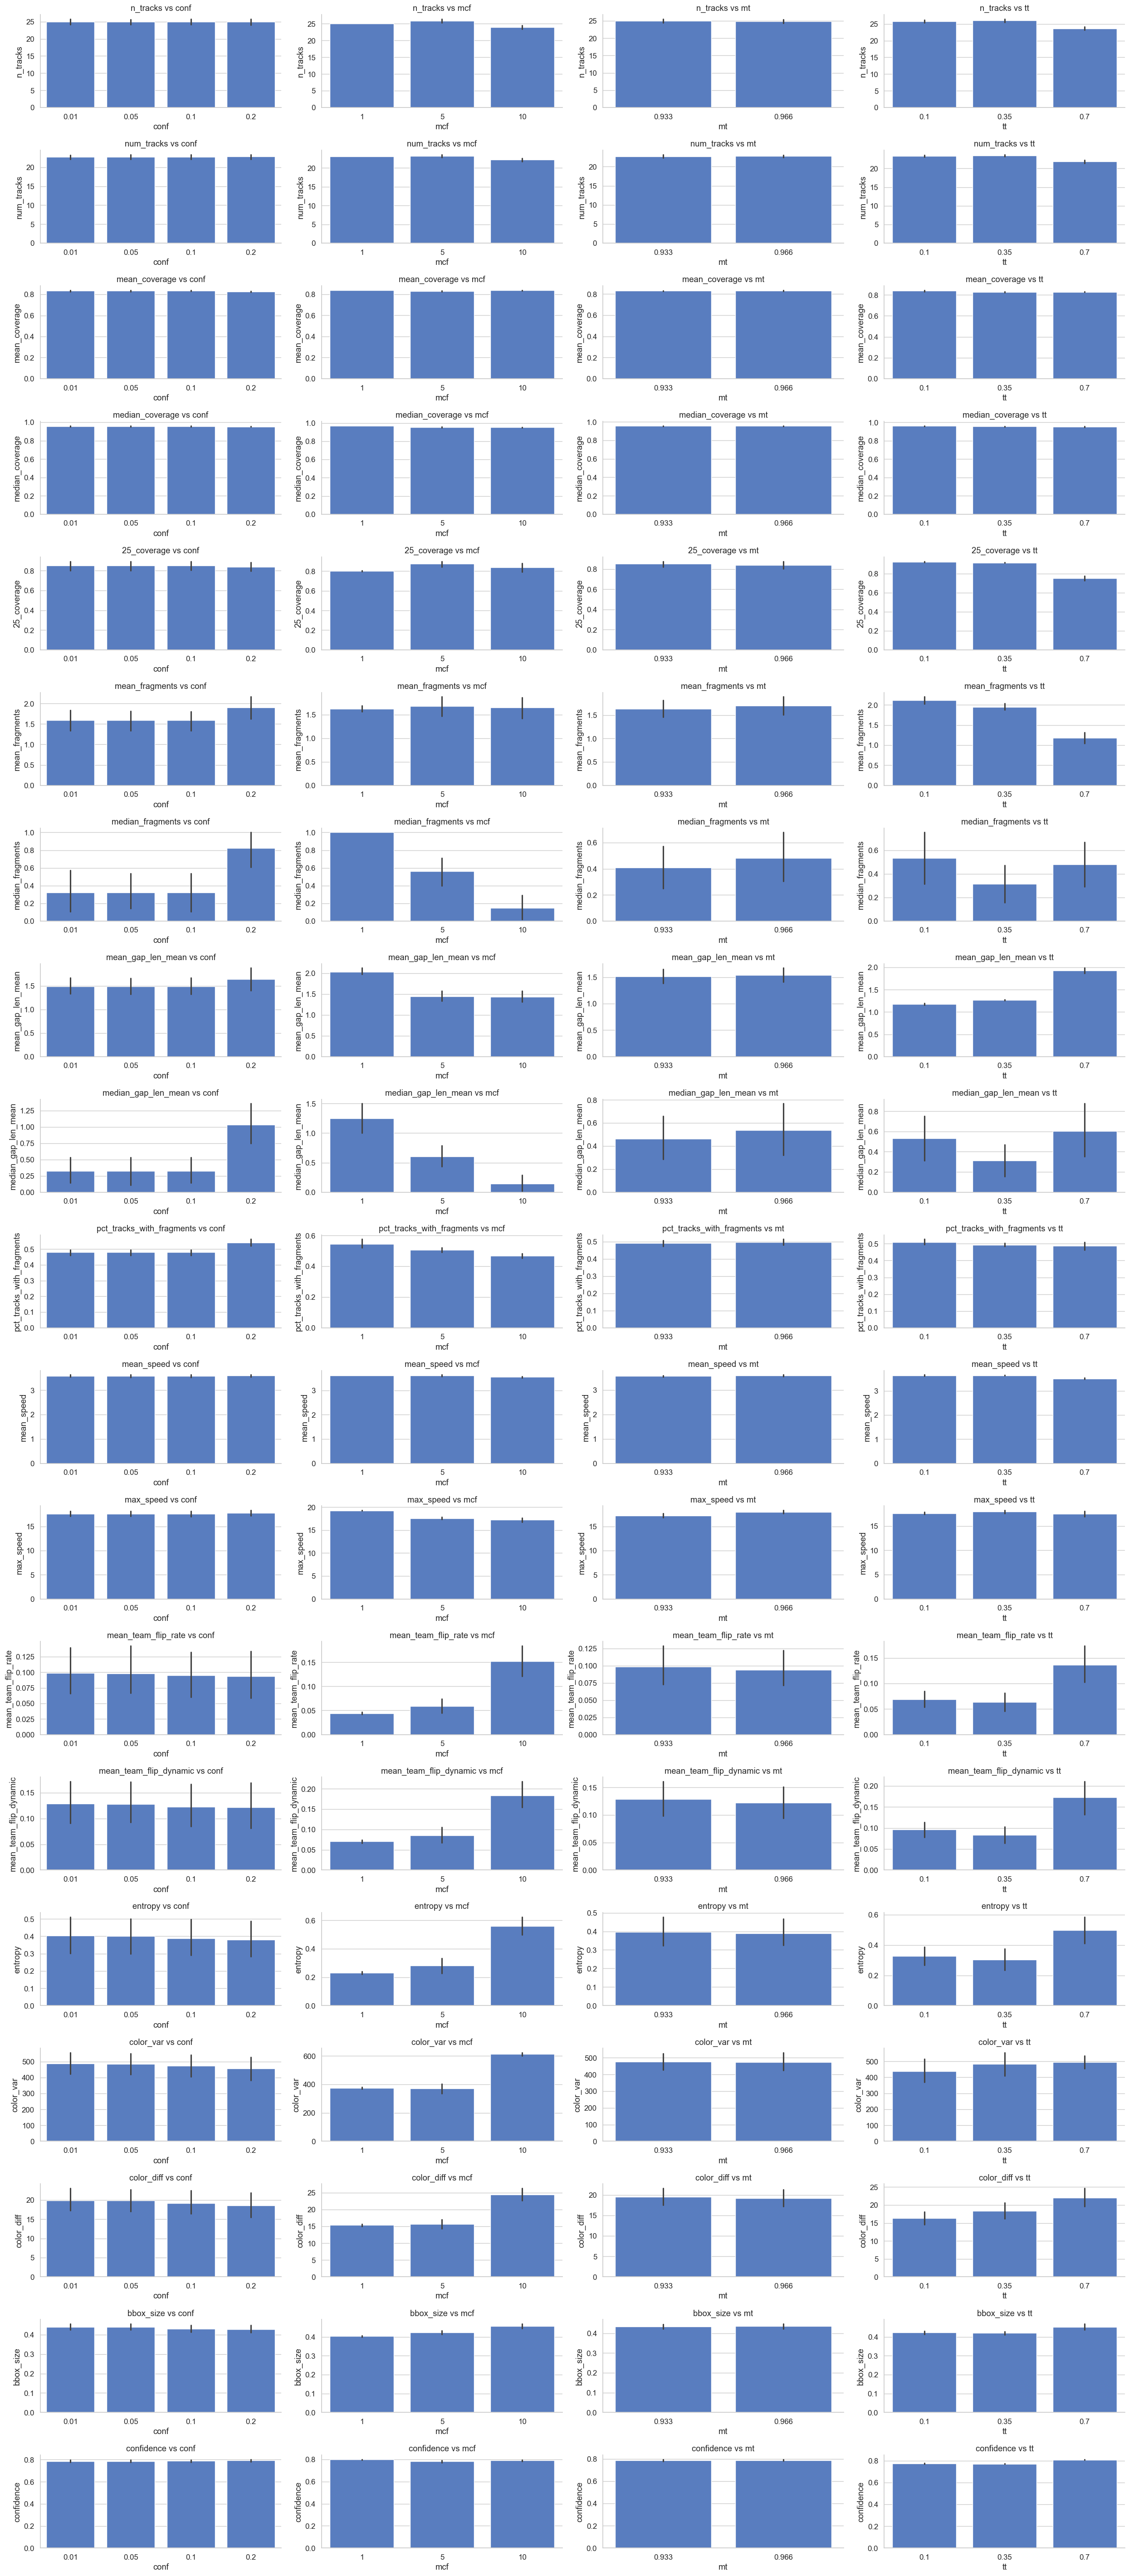

In [15]:
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

params = ['conf', 'mcf', 'mt', 'tt']

nrows = len(df_summary.columns[5:])
ncols = len(params)
fig, axes = plt.subplots(nrows, ncols, figsize=(25, nrows*3))
for i, c in enumerate(df_summary.columns[5:]):
    for j, p in enumerate(params):
        sns.barplot(data=df_summary, x=p, y=c, ax=axes[i, j])
        axes[i, j].set_title(f"{c} vs {p}"), axes[i, j].set_xlabel(p), axes[i, j].set_ylabel(c)

plt.tight_layout()
sns.despine()
plt.show()


In [16]:
df_summary.corr().iloc[5:, 5:]

,n_tracks,num_tracks,mean_coverage,median_coverage,25_coverage,mean_fragments,median_fragments,mean_gap_len_mean,median_gap_len_mean,pct_tracks_with_fragments,mean_speed,max_speed,mean_team_flip_rate,mean_team_flip_dynamic,entropy,color_var,color_diff,bbox_size,confidence
n_tracks,1.000000,0.966324,0.015134,0.538490,0.847743,0.778873,0.379500,-0.613251,0.292412,0.562383,0.885247,0.515171,-0.922508,-0.931257,-0.929262,-0.710954,-0.895844,-0.894229,-0.887599
num_tracks,0.966324,1.000000,0.026057,0.531068,0.821705,0.818963,0.346697,-0.583050,0.277416,0.585215,0.917502,0.635431,-0.934518,-0.945520,-0.914584,-0.605357,-0.863038,-0.893333,-0.873960
mean_coverage,0.015134,0.026057,1.000000,0.447687,0.385267,0.327151,-0.024052,-0.271536,-0.038439,-0.005481,0.272024,0.152061,-0.109164,-0.115797,-0.050692,0.133871,-0.069187,-0.154415,-0.117110
median_coverage,0.538490,0.531068,0.447687,1.000000,0.463571,0.531539,0.507054,-0.217611,0.461309,0.496636,0.660888,0.585194,-0.563484,-0.573762,-0.624411,-0.533977,-0.579435,-0.683597,-0.514734
25_coverage,0.847743,0.821705,0.385267,0.463571,1.000000,0.860764,0.080447,-0.841710,-0.000669,0.326974,0.805802,0.318498,-0.722425,-0.739287,-0.679034,-0.328686,-0.645165,-0.711756,-0.898659
mean_fragments,0.778873,0.818963,0.327151,0.531539,0.860764,1.000000,0.328066,-0.719983,0.257197,0.567572,0.893200,0.511145,-0.694569,-0.719952,-0.664414,-0.330030,-0.640533,-0.746898,-0.841752
median_fragments,0.379500,0.346697,-0.024052,0.507054,0.080447,0.328066,1.000000,0.230178,0.936324,0.828723,0.429897,0.510481,-0.492124,-0.479193,-0.563497,-0.724692,-0.624349,-0.563595,-0.114847
mean_gap_len_mean,-0.613251,-0.583050,-0.271536,-0.217611,-0.841710,-0.719983,0.230178,1.000000,0.361299,0.067677,-0.609184,0.030378,0.356795,0.386237,0.321250,0.049757,0.302941,0.342054,0.861004
median_gap_len_mean,0.292412,0.277416,-0.038439,0.461309,-0.000669,0.257197,0.936324,0.361299,1.000000,0.876115,0.338925,0.508174,-0.446552,-0.431766,-0.506393,-0.646198,-0.557461,-0.509517,-0.001962
pct_tracks_with_fragments,0.562383,0.585215,-0.005481,0.496636,0.326974,0.567572,0.828723,0.067677,0.876115,1.000000,0.604955,0.651502,-0.673939,-0.666875,-0.694010,-0.643200,-0.714414,-0.713705,-0.316210


In [17]:
df_summary.sort_values(by="median_fragments", ascending=False)

,conf,mcf,mt,tt,experiment_id,n_tracks,num_tracks,mean_coverage,median_coverage,25_coverage,...,pct_tracks_with_fragments,mean_speed,max_speed,mean_team_flip_rate,mean_team_flip_dynamic,entropy,color_var,color_diff,bbox_size,confidence
4,0.01,5,0.966,0.10,4,26,23,0.861087,0.9700,0.94000,...,0.521739,3.717698,17.881530,0.040662,0.062085,0.224816,283.403315,12.734184,0.413854,0.775655
45,0.05,1,0.933,0.70,45,25,23,0.837174,0.9700,0.80500,...,0.521739,3.609133,19.233587,0.047678,0.076380,0.246512,385.700875,15.966652,0.406291,0.798047
21,0.01,1,0.966,0.70,21,25,23,0.837174,0.9700,0.80500,...,0.521739,3.609036,19.233587,0.046629,0.075322,0.243073,381.690121,15.801428,0.406789,0.797871
18,0.01,1,0.933,0.70,18,25,23,0.837174,0.9700,0.80500,...,0.521739,3.609036,19.233587,0.047678,0.076380,0.246512,385.707840,15.966493,0.406333,0.797871
31,0.05,5,0.966,0.10,31,26,23,0.861087,0.9700,0.94000,...,0.521739,3.716829,17.881530,0.039536,0.061174,0.219659,280.692095,12.604013,0.413794,0.776091
72,0.10,1,0.933,0.70,72,25,23,0.837174,0.9700,0.80500,...,0.521739,3.608433,19.233587,0.043086,0.067706,0.227251,368.500908,15.030723,0.401470,0.798928
58,0.10,5,0.966,0.10,58,26,23,0.861087,0.9700,0.94000,...,0.521739,3.716185,17.773646,0.035816,0.054254,0.202948,263.124262,11.673403,0.398867,0.776958
48,0.05,1,0.966,0.70,48,25,23,0.837174,0.9700,0.80500,...,0.521739,3.609133,19.233587,0.046629,0.075322,0.243073,381.683033,15.801586,0.406746,0.798047
104,0.20,10,0.966,0.70,104,22,21,0.815714,0.9450,0.63500,...,0.523810,3.490224,17.186509,0.238802,0.278693,0.766334,628.177872,29.995825,0.500849,0.815169
83,0.20,10,0.933,0.10,83,25,23,0.837826,0.9500,0.90250,...,0.521739,3.604666,17.049810,0.096940,0.128437,0.433330,535.490630,17.777632,0.430730,0.784057
